# LFFHG8 Plasmidsaurus Data: What Happened?

This notebook summarizes the full analysis in plain language, with figures.

## Executive takeaway
- A small minority of reads are the expected amplicon (4/4586 mapped to the gBlock reference).
- The majority signal is a different, longer sequence.
- That dominant sequence contains synthetic `R1`-like sequence near both ends, and a long internal segment that aligns to human ribosomal DNA/rRNA loci.
- The gapped reference (`gblock_f1r1_gapped.gb`) improves quality metrics for the minority target-like reads, but does **not** increase target read count.


In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Seq import Seq

plt.style.use('seaborn-v0_8-whitegrid')

project_root = Path.cwd()
if not (project_root / 'results').exists():
    project_root = Path('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments')

out_dir = project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'story_figures'
out_dir.mkdir(parents=True, exist_ok=True)

paths = {
    'reads_fastq': project_root / 'data' / 'reads' / 'LFFHG8_fastq' / 'LFFHG8_1_pcr1_sub5.fastq',
    'ref_gb': project_root / 'data' / 'references' / 'gblock_f1r1_gapped.gb',
    'flagstat_orig': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.flagstat.txt',
    'flagstat_gapped': project_root / 'results' / 'LFFHG8_1_pcr1_sub5_gappedref' / 'LFFHG8_1_pcr1_sub5_gappedref.flagstat.txt',
    'mapped_ids': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.mapped_read_ids.txt',
    'feature_summary': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.feature_coverage.summary.tsv',
    'primer_summary': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'primer_positive_3.vs_gblock.sr.summary.tsv',
    'mapped_compare': project_root / 'results' / 'LFFHG8_1_pcr1_sub5_gappedref' / 'mapped4_ref_compare.tsv',
    'consensus_fa': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.consensus.fasta',
    'consensus_summary': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.consensus_summary.tsv',
    'blast_txt': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_contaminant_seed_UBZG1Y0H016_core_nt_blast_alignment.txt',
}

for k, p in paths.items():
    if not p.exists():
        raise FileNotFoundError(f"Missing required file for notebook: {k} -> {p}")

paths

{'reads_fastq': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/data/reads/LFFHG8_fastq/LFFHG8_1_pcr1_sub5.fastq'),
 'ref_gb': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/data/references/gblock_f1r1_gapped.gb'),
 'flagstat_orig': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results/LFFHG8_1_pcr1_sub5/LFFHG8_1_pcr1_sub5.flagstat.txt'),
 'flagstat_gapped': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results/LFFHG8_1_pcr1_sub5_gappedref/LFFHG8_1_pcr1_sub5_gappedref.flagstat.txt'),
 'mapped_ids': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results/LFFHG8_1_pcr1_sub5/LFFHG8_1_pcr1_sub5.mapped_read_ids.txt'),
 'feature_summary': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results/LFFHG8_1_pcr1_sub5/LFFHG8_1_pcr1_sub5.feature_coverage.summary.tsv'),
 'primer_summary': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results

In [2]:
def read_fastq_table(fastq_path: Path) -> pd.DataFrame:
    rows = []
    with fastq_path.open() as fh:
        while True:
            h = fh.readline().strip()
            if not h:
                break
            seq = fh.readline().strip()
            fh.readline()
            fh.readline()
            rid = h[1:].split()[0]
            rows.append({'read_id': rid, 'length': len(seq), 'seq': seq})
    return pd.DataFrame(rows)


def parse_flagstat(flagstat_path: Path):
    total = mapped = None
    for line in flagstat_path.read_text().splitlines():
        m_total = re.match(r'^(\d+) \+ \d+ in total', line)
        m_mapped = re.match(r'^(\d+) \+ \d+ mapped', line)
        if m_total:
            total = int(m_total.group(1))
        if m_mapped:
            mapped = int(m_mapped.group(1))
    return total, mapped


def load_primers_from_gb(gb_path: Path):
    rec = SeqIO.read(gb_path, 'genbank')
    ref_seq = rec.seq
    primers = {}
    for feat in rec.features:
        if feat.type != 'primer':
            continue
        label = feat.qualifiers.get('label', ['unnamed_primer'])[0]
        start0 = int(feat.location.start)
        end0 = int(feat.location.end)
        templ = str(ref_seq[start0:end0]).upper()
        if feat.location.strand == -1:
            primer = str(Seq(templ).reverse_complement())
        else:
            primer = templ
        primers[label] = {
            'primer_seq': primer,
            'template_seq': templ,
            'start_1based': start0 + 1,
            'end_1based': end0,
            'strand': feat.location.strand,
        }
    return primers

reads_df = read_fastq_table(paths['reads_fastq'])
primers = load_primers_from_gb(paths['ref_gb'])

f1_seq = primers['F1 primer']['primer_seq']
r1_seq = primers['R1 primer']['primer_seq']
r1_rc = str(Seq(r1_seq).reverse_complement())

reads_df['f1_pos'] = reads_df['seq'].str.find(f1_seq)
reads_df['has_f1'] = reads_df['f1_pos'] >= 0
reads_df['has_r1'] = reads_df['seq'].str.contains(r1_seq)

mapped_ids = [x.strip() for x in paths['mapped_ids'].read_text().splitlines() if x.strip()]
reads_df['is_mapped_to_gblock'] = reads_df['read_id'].isin(mapped_ids)

total_reads, mapped_reads = parse_flagstat(paths['flagstat_orig'])
total_reads_gapped, mapped_reads_gapped = parse_flagstat(paths['flagstat_gapped'])

feature_summary = pd.read_csv(paths['feature_summary'], sep='	')
primer_summary = pd.read_csv(paths['primer_summary'], sep='	')
mapped_compare = pd.read_csv(paths['mapped_compare'], sep='	')
cons_summary = pd.read_csv(paths['consensus_summary'], sep='	')

cons_rec = next(SeqIO.parse(paths['consensus_fa'], 'fasta'))
consensus_seq = str(cons_rec.seq).upper()

primer41 = 'CTGCAGTGACTTTAATATACGCTATTGGAGCTGGAATTACC'
primer41_pos = consensus_seq.find(primer41)
left_r1_pos = consensus_seq.find(r1_seq)
right_r1rc_pos = consensus_seq.find(r1_rc)

summary = {
    'total_reads': total_reads,
    'mapped_reads': mapped_reads,
    'mapped_pct': mapped_reads / total_reads * 100,
    'f1_positive_reads': int(reads_df['has_f1'].sum()),
    'consensus_length': len(consensus_seq),
    'consensus_seed_mapped_reads': cons_summary.loc[0, 'mapped_reads'],
    'left_r1_pos_1based': left_r1_pos + 1 if left_r1_pos >= 0 else None,
    'right_r1rc_pos_1based': right_r1rc_pos + 1 if right_r1rc_pos >= 0 else None,
    'primer41_pos_1based': primer41_pos + 1 if primer41_pos >= 0 else None,
}

summary

{'total_reads': 4586,
 'mapped_reads': 4,
 'mapped_pct': 0.08722197993894462,
 'f1_positive_reads': 3,
 'consensus_length': 1611,
 'consensus_seed_mapped_reads': '1046 (21.54)',
 'left_r1_pos_1based': 7,
 'right_r1rc_pos_1based': 1591,
 'primer41_pos_1based': None}

## 1) Target mapping is rare
Only a tiny fraction of reads map to the expected gBlock amplicon reference.

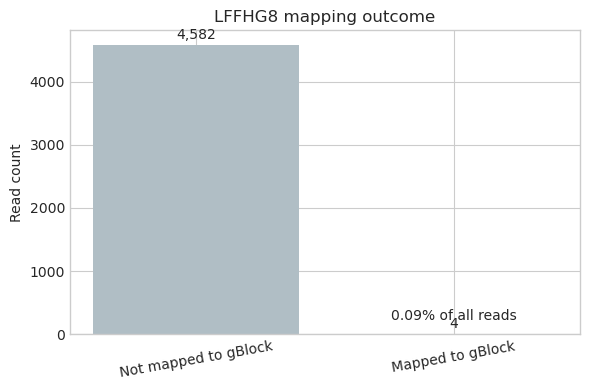

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
vals = [summary['total_reads'] - summary['mapped_reads'], summary['mapped_reads']]
labels = ['Not mapped to gBlock', 'Mapped to gBlock']
colors = ['#b0bec5', '#2a9d8f']
ax.bar(labels, vals, color=colors)
ax.set_ylabel('Read count')
ax.set_title('LFFHG8 mapping outcome')
for i, v in enumerate(vals):
    ax.text(i, v + max(vals) * 0.01, f'{v:,}', ha='center', va='bottom', fontsize=10)
ax.text(1, vals[1] + max(vals) * 0.05, f"{summary['mapped_pct']:.2f}% of all reads", ha='center', fontsize=10)
plt.xticks(rotation=10)
plt.tight_layout()
fig.savefig(out_dir / '01_mapping_outcome.png', dpi=180)
plt.show()

## 2) The expected product exists, but as a minority
Forward-primer-positive reads are present and have expected amplicon-like lengths (~300 bp), but they are rare compared with the full dataset.

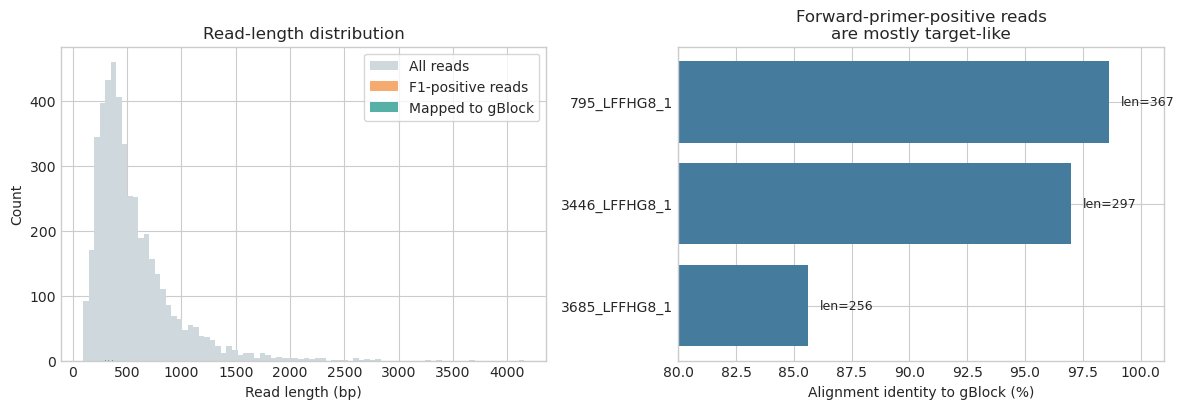

,read_id,length,f1_pos
3446,3446_LFFHG8_1,297,0
3685,3685_LFFHG8_1,256,0
795,795_LFFHG8_1,367,0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(reads_df['length'], bins=80, color='#cfd8dc', edgecolor='none', label='All reads')
axes[0].hist(reads_df.loc[reads_df['has_f1'], 'length'], bins=20, color='#f4a261', alpha=0.9, label='F1-positive reads')
axes[0].hist(reads_df.loc[reads_df['is_mapped_to_gblock'], 'length'], bins=20, color='#2a9d8f', alpha=0.8, label='Mapped to gBlock')
axes[0].set_xlabel('Read length (bp)')
axes[0].set_ylabel('Count')
axes[0].set_title('Read-length distribution')
axes[0].legend(frameon=True)

plot_df = primer_summary.copy()
plot_df = plot_df.sort_values('qlen')
axes[1].barh(plot_df['query'], plot_df['identity'] * 100, color='#457b9d')
for y, (_, row) in enumerate(plot_df.iterrows()):
    axes[1].text(row['identity'] * 100 + 0.5, y, f"len={int(row['qlen'])}", va='center', fontsize=9)
axes[1].set_xlim(80, 101)
axes[1].set_xlabel('Alignment identity to gBlock (%)')
axes[1].set_title('Forward-primer-positive reads\nare mostly target-like')

plt.tight_layout()
fig.savefig(out_dir / '02_length_and_primer_positive.png', dpi=180)
plt.show()

reads_df.loc[reads_df['has_f1'], ['read_id', 'length', 'f1_pos']].sort_values('read_id')

## 3) Coverage over annotated reference features
For the few mapped reads, coverage spans expected annotated regions including primer features and internal annotations.

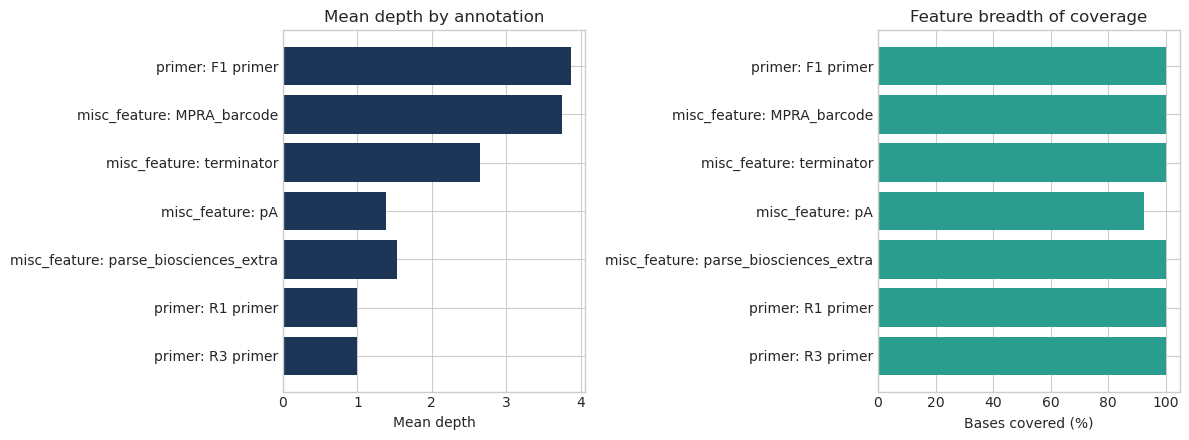

In [5]:
feat_plot = feature_summary[['feature_id', 'feature_type', 'mean_depth', 'frac_bases_covered']].copy()
feat_plot['label'] = feat_plot['feature_type'] + ': ' + feat_plot['feature_id']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].barh(feat_plot['label'], feat_plot['mean_depth'], color='#1d3557')
axes[0].set_xlabel('Mean depth')
axes[0].set_title('Mean depth by annotation')

axes[1].barh(feat_plot['label'], feat_plot['frac_bases_covered'] * 100, color='#2a9d8f')
axes[1].set_xlabel('Bases covered (%)')
axes[1].set_xlim(0, 105)
axes[1].set_title('Feature breadth of coverage')

for ax in axes:
    ax.invert_yaxis()

plt.tight_layout()
fig.savefig(out_dir / '03_feature_coverage.png', dpi=180)
plt.show()

## 4) Gapped reference helps quality, not sensitivity
Replacing barcode bases with ambiguity (`N`) did not increase the number of mapped reads, but improved alignment quality metrics for the mapped minority.

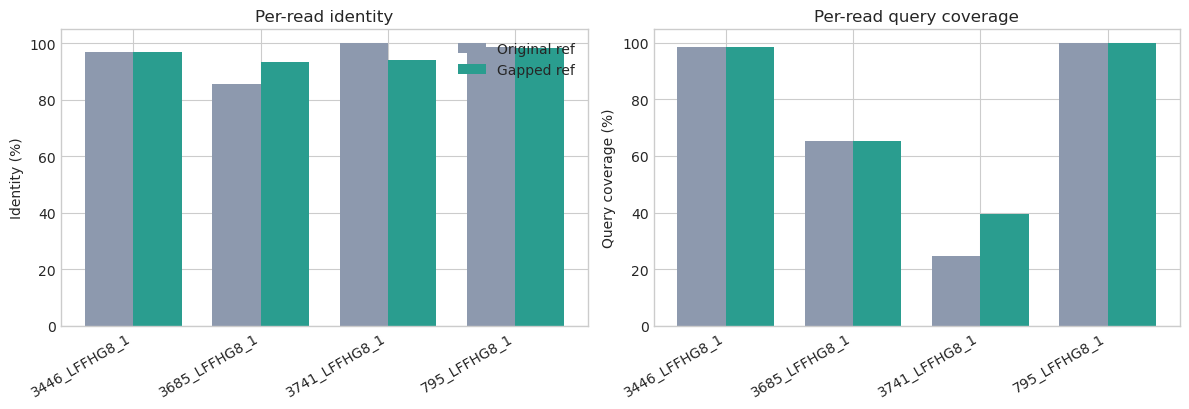

,read_id,orig_identity,gapped_identity,delta_identity,orig_query_cov,gapped_query_cov,delta_query_cov,orig_ref_span,gapped_ref_span
0,3446_LFFHG8_1,0.9700,0.9701,0.0001,0.9865,0.9865,0.0000,300,300
1,3685_LFFHG8_1,0.8563,0.9338,0.0775,0.6523,0.6523,0.0000,163,163
2,3741_LFFHG8_1,1.0000,0.9397,-0.0603,0.2454,0.3957,0.1503,80,128
3,795_LFFHG8_1,0.9864,0.9842,-0.0021,0.9973,0.9973,0.0000,367,367


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

x = np.arange(len(mapped_compare))
w = 0.38

axes[0].bar(x - w/2, mapped_compare['orig_identity'] * 100, width=w, label='Original ref', color='#8d99ae')
axes[0].bar(x + w/2, mapped_compare['gapped_identity'] * 100, width=w, label='Gapped ref', color='#2a9d8f')
axes[0].set_xticks(x)
axes[0].set_xticklabels(mapped_compare['read_id'], rotation=30, ha='right')
axes[0].set_ylabel('Identity (%)')
axes[0].set_title('Per-read identity')
axes[0].legend()

axes[1].bar(x - w/2, mapped_compare['orig_query_cov'] * 100, width=w, label='Original ref', color='#8d99ae')
axes[1].bar(x + w/2, mapped_compare['gapped_query_cov'] * 100, width=w, label='Gapped ref', color='#2a9d8f')
axes[1].set_xticks(x)
axes[1].set_xticklabels(mapped_compare['read_id'], rotation=30, ha='right')
axes[1].set_ylabel('Query coverage (%)')
axes[1].set_title('Per-read query coverage')

plt.tight_layout()
fig.savefig(out_dir / '04_gapped_vs_original.png', dpi=180)
plt.show()

mapped_compare

## 5) Dominant contaminant architecture
The consensus of the dominant sequence cluster is ~1.6 kb and has this structure:
- `R1`-like sequence near the left end.
- Long internal segment that aligns strongly to human 18S/rDNA-related sequence.
- `R1` reverse-complement-like sequence near the right end.

The exact coordinates below are in consensus-space (1-based).

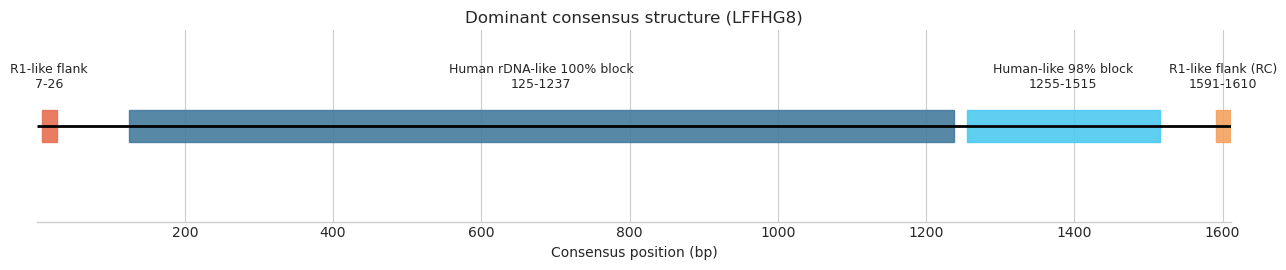

,element,start_1based,end_1based
0,R1-like left flank,7.0,26.0
1,41 bp motif,NaN,NaN
2,Human 100% block,125.0,1237.0
3,Human 98% block,1255.0,1515.0
4,R1-like right flank (RC),1591.0,1610.0


In [7]:
# Coordinates from our previous BLAST/clustal inspection
cons_len = len(consensus_seq)

# From BLAST report against NR_146144.1 section:
perfect_human_start, perfect_human_end = 125, 1237   # 1113/1113, 100%
nearperfect_human_start, nearperfect_human_end = 1255, 1515  # 256/261, 98%

# From direct motif scans on consensus:
left_r1_start = summary['left_r1_pos_1based']
left_r1_end = left_r1_start + len(r1_seq) - 1
right_r1rc_start = summary['right_r1rc_pos_1based']
right_r1rc_end = right_r1rc_start + len(r1_rc) - 1
motif41_start = summary['primer41_pos_1based']
motif41_end = motif41_start + len(primer41) - 1 if motif41_start is not None else None

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.hlines(1, 1, cons_len, color='black', linewidth=2)

# helper
def draw_block(start, end, color, label, y=1, h=0.18):
    ax.add_patch(plt.Rectangle((start, y - h/2), end - start + 1, h, color=color, alpha=0.9))
    ax.text((start + end) / 2, y + 0.2, f"{label}\n{start}-{end}", ha='center', va='bottom', fontsize=9)

draw_block(left_r1_start, left_r1_end, '#e76f51', 'R1-like flank')
draw_block(perfect_human_start, perfect_human_end, '#457b9d', 'Human rDNA-like 100% block')
draw_block(nearperfect_human_start, nearperfect_human_end, '#4cc9f0', 'Human-like 98% block')
draw_block(right_r1rc_start, right_r1rc_end, '#f4a261', 'R1-like flank (RC)')
if motif41_start is not None:
    draw_block(motif41_start, motif41_end, '#6a994e', '41 bp motif', y=0.72, h=0.12)

ax.set_xlim(1, cons_len)
ax.set_ylim(0.45, 1.55)
ax.set_yticks([])
ax.set_xlabel('Consensus position (bp)')
ax.set_title('Dominant consensus structure (LFFHG8)')

for spine in ['left', 'right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
fig.savefig(out_dir / '05_consensus_architecture.png', dpi=180)
plt.show()

pd.DataFrame([
    {'element': 'R1-like left flank', 'start_1based': left_r1_start, 'end_1based': left_r1_end},
    {'element': '41 bp motif', 'start_1based': motif41_start, 'end_1based': motif41_end},
    {'element': 'Human 100% block', 'start_1based': perfect_human_start, 'end_1based': perfect_human_end},
    {'element': 'Human 98% block', 'start_1based': nearperfect_human_start, 'end_1based': nearperfect_human_end},
    {'element': 'R1-like right flank (RC)', 'start_1based': right_r1rc_start, 'end_1based': right_r1rc_end},
])

## 6) How many reads are R1-like flanked on both sides?
To quantify this rigorously, we scored each read end with local alignment against `R1` and `revcomp(R1)`.

Criteria for a side-hit:
- aligned primer bases >= 12
- identity >= 80%

A read is called **flanked** if both ends pass (any orientation pairing).
This allows mismatches and truncation while still requiring primer-like signal at both ends.


R1-like flanked reads: 2819/4586 (61.47%)
Left-end hit rate: 76.12%
Right-end hit rate: 73.46%


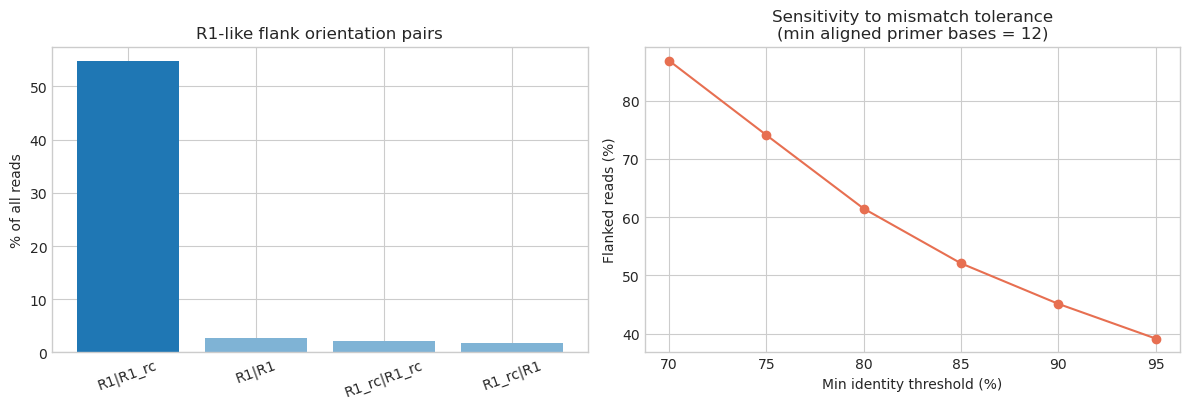

,orientation,count,pct_of_all_reads,pct_of_flanked_reads
0,R1|R1_rc,2510,0.547318,0.890387
1,R1|R1,126,0.027475,0.044697
2,R1_rc|R1_rc,102,0.022242,0.036183
3,R1_rc|R1,81,0.017662,0.028734


In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

r1_summary_path = project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'r1_flank_any_orientation.summary.tsv'
r1_orient_path = project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'r1_flank_any_orientation.orientation_counts.tsv'
r1_grid_path = project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'r1_flank_any_orientation.threshold_grid.tsv'

if not (r1_summary_path.exists() and r1_orient_path.exists() and r1_grid_path.exists()):
    raise FileNotFoundError(
        'Missing R1 flank metrics. Run scripts/quantify_r1_flanked_reads.py first.'
    )

r1_summary = pd.read_csv(r1_summary_path, sep='	')
r1_orient = pd.read_csv(r1_orient_path, sep='	')
r1_grid = pd.read_csv(r1_grid_path, sep='	')

s = dict(zip(r1_summary['metric'], r1_summary['value']))
print(f"R1-like flanked reads: {int(s['flanked_reads'])}/{int(s['total_reads'])} ({s['flanked_pct']*100:.2f}%)")
print(f"Left-end hit rate: {s['left_hit_pct']*100:.2f}%")
print(f"Right-end hit rate: {s['right_hit_pct']*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Orientation breakdown
order = r1_orient.sort_values('count', ascending=False)
axes[0].bar(order['orientation'], order['pct_of_all_reads'] * 100, color=['#1f77b4', '#7fb3d5', '#7fb3d5', '#7fb3d5'])
axes[0].set_ylabel('% of all reads')
axes[0].set_title('R1-like flank orientation pairs')
axes[0].tick_params(axis='x', rotation=20)

# Sensitivity across identity threshold at fixed min_aln_len=12
g = r1_grid[r1_grid['min_aln_len'] == 12].sort_values('min_identity')
axes[1].plot(g['min_identity'] * 100, g['flanked_pct'] * 100, marker='o', color='#e76f51')
axes[1].set_xlabel('Min identity threshold (%)')
axes[1].set_ylabel('Flanked reads (%)')
axes[1].set_title('Sensitivity to mismatch tolerance\n(min aligned primer bases = 12)')

plt.tight_layout()
out = out_dir / '06_r1_flanked_prevalence.png'
fig.savefig(out, dpi=180)
plt.show()

r1_orient

## 7) Human RNA-cDNA explainability (transcriptome-only test)
Each read was aligned to a pinned human transcriptome reference (GENCODE v48).

Default call used here:
- `best_query_cov >= 0.50`
- `best_identity >= 0.80`

This section estimates how much of the sample can be explained as human RNA-cDNA-like sequence under those criteria.


Explained reads: 620/4586 (13.52%)
Mapped-to-human reads: 2441/4586 (53.23%)
Explained bases fraction: 14.18%


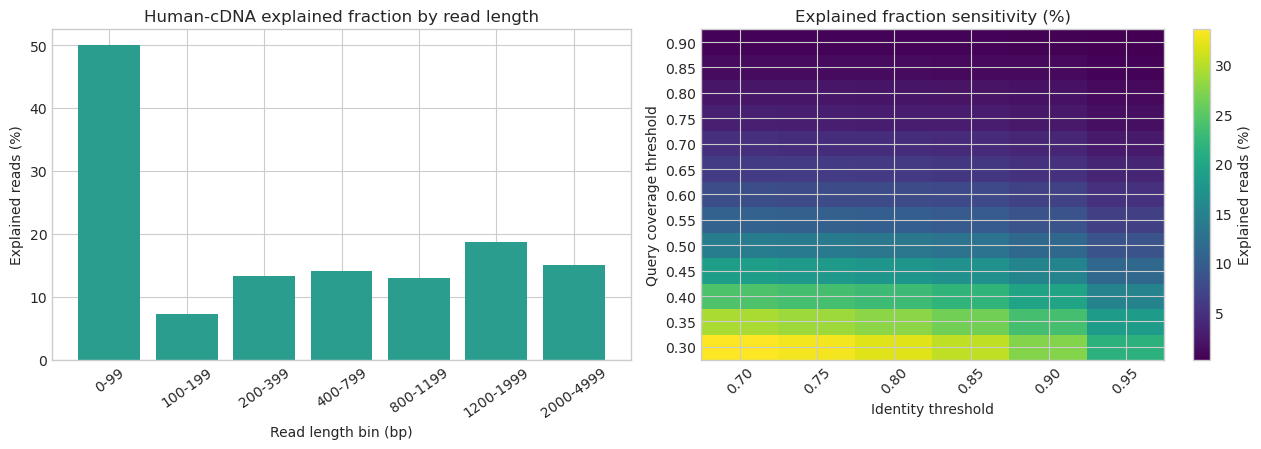

,transcript_id,gene_id,gene_name,transcript_name,biotype,mapped_reads,explained_reads,mean_best_identity,mean_best_query_cov
0,ENST00000389680.2,ENSG00000211459.2,MT-RNR1,MT-RNR1-201,Mt_rRNA,117,42,0.948996,0.468944
1,ENST00000631211.1,ENSG00000280800.1,ENSG00000280800,ENST00000631211,lncRNA,80,38,0.952509,0.482632
2,ENST00000627981.1,ENSG00000281181.1,ENSG00000281181,ENST00000627981,lncRNA,78,37,0.950495,0.494916
3,ENST00000673528.1,ENSG00000288444.1,ENSG00000288444,ENST00000673528,lncRNA,75,37,0.950837,0.499913
4,ENST00000673221.1,ENSG00000288254.1,ENSG00000288254,ENST00000673221,lncRNA,82,27,0.956090,0.452121
5,ENST00000387347.2,ENSG00000210082.2,MT-RNR2,MT-RNR2-201,Mt_rRNA,85,25,0.947631,0.453380
6,ENST00000625598.1,ENSG00000280614.1,ENSG00000280614,ENST00000625598,lncRNA,55,23,0.940974,0.500917
7,ENST00000629969.1,ENSG00000281383.1,ENSG00000281383,ENST00000629969,lncRNA,36,12,0.974188,0.412041
8,ENST00000849367.1,ENSG00000310376.1,ENSG00000310376,ENST00000849367,lncRNA,87,9,0.956031,0.317515
9,ENST00000361624.2,ENSG00000198804.2,MT-CO1,MT-CO1-201,protein_coding,7,4,0.966558,0.539530


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

base = project_root / 'results' / 'LFFHG8_1_pcr1_sub5'
summary_path = base / 'human_cdna_explainability.summary.tsv'
length_path = base / 'human_cdna_explainability.length_binned.tsv'
grid_path = base / 'human_cdna_explainability.threshold_grid.tsv'
top_targets_path = base / 'human_cdna_explainability.top_targets.tsv'

for p in [summary_path, length_path, grid_path, top_targets_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required file for human-cDNA section: {p}')

summary = pd.read_csv(summary_path, sep='	')
length_df = pd.read_csv(length_path, sep='	')
grid = pd.read_csv(grid_path, sep='	')
top_targets = pd.read_csv(top_targets_path, sep='	')

s = dict(zip(summary['metric'], summary['value']))
print(f"Explained reads: {int(s['explained_reads'])}/{int(s['total_reads'])} ({s['reads_explained_fraction']*100:.2f}%)")
print(f"Mapped-to-human reads: {int(s['mapped_to_human_reads'])}/{int(s['total_reads'])} ({s['mapped_to_human_fraction']*100:.2f}%)")
print(f"Explained bases fraction: {s['bases_explained_fraction']*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# Left: explained fraction by read-length bin
plot_len = length_df.copy()
axes[0].bar(plot_len['length_bin'], plot_len['explained_fraction'] * 100, color='#2a9d8f')
axes[0].set_ylabel('Explained reads (%)')
axes[0].set_xlabel('Read length bin (bp)')
axes[0].set_title('Human-cDNA explained fraction by read length')
axes[0].tick_params(axis='x', rotation=35)

# Right: threshold sensitivity heatmap (coverage x identity)
pivot = grid.pivot(index='query_cov_threshold', columns='identity_threshold', values='explained_fraction')
im = axes[1].imshow(pivot.values * 100, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_xticks(range(len(pivot.columns)))
axes[1].set_xticklabels([f"{x:.2f}" for x in pivot.columns], rotation=45)
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_yticklabels([f"{x:.2f}" for x in pivot.index])
axes[1].set_xlabel('Identity threshold')
axes[1].set_ylabel('Query coverage threshold')
axes[1].set_title('Explained fraction sensitivity (%)')

cbar = fig.colorbar(im, ax=axes[1])
cbar.set_label('Explained reads (%)')

plt.tight_layout()
fig.savefig(out_dir / '07_human_cdna_explainability.png', dpi=180)
plt.show()

top_targets.head(15)

## 8) Contaminant pre-exists in the pure cDNA sublibraries

To determine whether the R2-flanked rDNA contaminant was introduced by the MPRA PCR step or was already present upstream, we obtained Plasmidsaurus long-read sequencing of two pure Parse Evercode WT cDNA sublibraries: **sublibrary 5** (3LV7H5_1 — the same sublibrary used to make LFFHG8) and **sublibrary 6** (3LV7H5_2 — prepared identically).

Each read set was aligned to the LFFHG8 contaminant consensus (1611 bp) with minimap2 (`map-ont`).

Key findings:
- **~12% of reads in both sublibraries map to the contaminant** (primary mapped, MAPQ mean ~54, >90% with MAPQ ≥ 30).
- **Coverage is full-length** in both: Sub5 99.9% breadth at 130× depth; Sub6 100% at 135× depth.
- The contaminant levels are nearly identical in Sub5 and Sub6, confirming it is a **systematic library-prep artifact**, not specific to Sub5 or to the MPRA PCR.
- Going from pure cDNA (~12%) to LFFHG8 (~21.5%) represents ~2× enrichment introduced by the MPRA PCR step (explained in Section 9).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Pre-computed alignment stats from samtools flagstat (vs. LFFHG8 contaminant consensus)
# Sub5 (3LV7H5_1): 592 primary mapped / 5000 total, MAPQ mean 54.7, 99.9% breadth
# Sub6 (3LV7H5_2): 614 primary mapped / 5000 total, MAPQ mean 54.1, 100.0% breadth
# LFFHG8: 1046 reads mapped to consensus seed / 4586 total (21.54%) from consensus_summary
sub5_mapped, sub5_total = 592, 5000
sub6_mapped, sub6_total = 614, 5000
lffhg8_contam_pct = float(str(summary['consensus_seed_mapped_reads']).split('(')[1].rstrip(')'))
lffhg8_total = summary['total_reads']

contam_pcts = [
    lffhg8_contam_pct,
    sub5_mapped / sub5_total * 100,
    sub6_mapped / sub6_total * 100,
]
libraries = ['LFFHG8\n(MPRA PCR product)', 'Sub5 3LV7H5_1\n(pure cDNA)', 'Sub6 3LV7H5_2\n(pure cDNA)']
colors = ['#e76f51', '#457b9d', '#2a9d8f']

# R1-flank summaries for sublibraries
sub5_r1_path = project_root / 'results' / '3LV7H5_1_sub5' / 'r1_flank.summary.tsv'
sub6_r1_path = project_root / 'results' / '3LV7H5_2_sub6' / 'r1_flank.summary.tsv'
sub5_r1 = dict(zip(*[pd.read_csv(sub5_r1_path, sep='\t')[c] for c in ['metric', 'value']]))
sub6_r1 = dict(zip(*[pd.read_csv(sub6_r1_path, sep='\t')[c] for c in ['metric', 'value']]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: contaminant mapping rate across libraries
axes[0].bar(libraries, contam_pcts, color=colors)
for i, v in enumerate(contam_pcts):
    axes[0].text(i, v + 0.4, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Reads mapping to contaminant (%)')
axes[0].set_title('Contaminant prevalence by library\n(aligned to LFFHG8 contaminant consensus)')
axes[0].set_ylim(0, max(contam_pcts) * 1.3)

# Right: R2-flank hit rates in sublibraries
metrics = ['left_hit_pct', 'right_hit_pct', 'flanked_pct']
xlabels = ['Left-end\nR2 hit', 'Right-end\nR2 hit', 'Both ends\n(flanked)']
x = range(len(metrics))
w = 0.35
axes[1].bar([i - w/2 for i in x], [sub5_r1[m]*100 for m in metrics], width=w,
            label='Sub5 (3LV7H5_1)', color='#457b9d')
axes[1].bar([i + w/2 for i in x], [sub6_r1[m]*100 for m in metrics], width=w,
            label='Sub6 (3LV7H5_2)', color='#2a9d8f')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(xlabels)
axes[1].set_ylabel('% of reads')
axes[1].set_title('TruSeq R2 primer–like flank rates\nin pure cDNA sublibraries')
axes[1].legend()
axes[1].set_ylim(0, 100)

plt.tight_layout()
fig.savefig(out_dir / '08_sublibrary_contaminant.png', dpi=180)
plt.show()

pd.DataFrame({
    'library': libraries,
    'total_reads': [int(lffhg8_total), sub5_total, sub6_total],
    'contaminant_reads': [1046, sub5_mapped, sub6_mapped],
    'contaminant_pct': [f'{p:.2f}%' for p in contam_pcts],
    'mean_mapq_vs_consensus': ['—', '54.7', '54.1'],
    'consensus_breadth': ['—', '99.9%', '100.0%'],
})

## 9) Mechanistic explanation: Parse Biosciences library structure

### Parse Evercode WT library structure

The TruSeq R2 sequencing primer site (`CAGACGTGTGCTCTTCCGATCT`) is embedded in the **Round 3 in-cell ligation barcode** oligo from the very beginning of library construction — it is **not** added late. After all three barcoding rounds, each assembled cDNA molecule has:

```
5'—[SMART/TSO]—[cDNA]—[BC1]—[linker]—[BC2]—[linker]—[BC3]—[10 bp UMI]—[TruSeq R2 site]—3'
```

The **Section 2 cDNA amplification PCR** uses two primers:
- **Amp Primer 1** (`CAGACGTGTGCTCTTCCGATCT` = TruSeq R2): primes from the R2/barcode (3') end
- **Amp Primer 2** (`AAGCAGTGGTATCAACGCAGAGT` = SMART/ISPCR): primes from the cDNA (5') end

TruSeq **R1** is added much later — by ligation to the 5' cDNA end in **Section 3** — and is therefore absent from the Section 2 amplified cDNA used as MPRA PCR template.

### How the R2-flanked rDNA artifact forms

1. **No ribo-depletion** → abundant rRNA is reverse-transcribed → the Section 2 cDNA is heavily loaded with rDNA molecules, each sharing the same TruSeq R2 site at its 3' end.
2. During **Section 2 PCR**, Amp Primer 1 (TruSeq R2) primes all molecules from the 3' end. With many rDNA molecules in the pool, inter-molecular template switching mediated by the shared R2 adapter creates chimeras with TruSeq R2 at **both** ends: `5'—[R2]—[rDNA ~1550 bp]—[R2_RC]—3'`.
3. These R2-rDNA-R2 chimeras are amplified by Amp Primer 1 alone from **both** ends, compounding with each PCR cycle.
4. Result: ~12% of Section 2 amplified cDNA maps to the rDNA contaminant (confirmed in both Sub5 and Sub6 at similar rates, indicating this is systematic to the library prep batch).

### Why the MPRA PCR enriches the contaminant ~2×

The MPRA enrichment PCR uses a GFP-specific forward primer + the TruSeq R2 reverse primer (Amp Primer 1 — the same primer, called "R1 primer" in the gblock annotation as it was used as the reverse PCR primer). The R2-rDNA-R2 contaminant is amplified by R2 alone from both ends without needing the GFP forward primer at all. This single-primer amplification advantage accounts for the ~2× enrichment from ~12% (pure cDNA sublibraries) → ~21% (LFFHG8 MPRA PCR product).

### Recommended fix

**Run the MPRA enrichment PCR post-fragmentation** (i.e., use the Section 3-fragmented library as template rather than the Section 2 amplified cDNA). After enzymatic fragmentation, the ~1611 bp R2-rDNA-R2 molecules are cut into ~300–500 bp pieces, each retaining R2 on at most one end. Single-primer amplification is eliminated, and rDNA fragments lack GFP sequence — so they are excluded by the GFP forward primer requirement. The specific MPRA amplicon (GFP → R2 site, ~370 bp) is short enough to survive fragmentation at a reasonable rate.

## Final interpretation

The data support this complete narrative:

1. **The intended amplicon is present, but rare.** Only 4/4586 reads (0.09%) map to the gBlock reference. Three forward-primer-positive reads exist with expected amplicon-like lengths, confirming the target was present at trace levels.

2. **The dominant contaminant is R2-flanked human rDNA.** The consensus (~1611 bp) has TruSeq R2 adapter sequence at both ends flanking ~1550 bp of human 18S/28S rDNA-like sequence. The `R1 primer` in the gblock annotation is identical to the TruSeq R2 sequencing primer and was used as the reverse primer in the MPRA PCR.

3. **The contaminant pre-exists in the cDNA library before any MPRA PCR.** Plasmidsaurus sequencing of pure cDNA sublibraries Sub5 (3LV7H5_1) and Sub6 (3LV7H5_2) shows ~12% of reads mapping to the contaminant consensus at high confidence (MAPQ ~54, full-length coverage). This rules out the MPRA PCR as the source.

4. **Root cause: Parse Evercode WT Section 2 cDNA amplification.** The TruSeq R2 site is embedded in the Round 3 in-cell ligation barcode from the start. The Section 2 amplification PCR uses Amp Primer 1 (= TruSeq R2) at the barcode end of all molecules. Abundant rDNA cDNA (no ribo-depletion) undergoes inter-molecular template switching during this PCR, creating R2-rDNA-R2 chimeras that are amplified by R2 alone from both ends.

5. **The MPRA PCR enriches the contaminant ~2×** because it also uses the TruSeq R2 primer, allowing R2-only single-primer amplification of the chimeric molecules (21.5% in LFFHG8 vs. ~12% in pure cDNA).

6. **Gapped reference helps quality, not sensitivity** — replacing barcode bases with N improves alignment identity for the minority target reads but does not increase mapping count.

### Recommended fix
Run the MPRA enrichment PCR on the **Section 3 fragmented library** rather than the Section 2 amplified cDNA. Fragmentation breaks the R2-rDNA-R2 molecules, eliminating their single-primer amplification advantage and removing them from the GFP-forward-primer selection.

Figures written to: `results/LFFHG8_1_pcr1_sub5/story_figures/`